# SLCM 0-5 Population: Part 1 Exploratory Data Analysis
Team: Niko Madden and AJ Rallo. Run in Google Colab with both CSVs in Google Drive at `My Drive/Group Project/`. Data: `cleaned_intakes_masked.csv` (one row per Jira ticket) and `household_members_long_v2.csv` (one row per additional household member).

**Ethics note:** files are de-identified. We make no attempt to re-identify anyone, and no free-text or name-like columns are displayed in this notebook.

**Analysis decisions (change the switches below to test alternatives):**
- `COUNT_7DAY_AS_RISK`: the 2 tickets with eviction status "Received 7 day notice" count as eviction-risk.
- `PID_BASE = 'all'`: repeat contact (Figure 2) counts a person's tickets of every type, as the assignment words it. Set it to `'intake'` to count intake tickets only.

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.patches import FancyBboxPatch
from google.colab import files
pd.set_option('display.width', 200, 'display.max_columns', 40, 'display.max_rows', 120)
sns.set_theme(style='whitegrid')

COUNT_7DAY_AS_RISK = True
PID_BASE = 'all'   

files.upload()

tix = pd.read_csv('cleaned_intakes_masked.csv', low_memory=False)
hh  = pd.read_csv('household_members_long_v2.csv')
ORIG_COLS = list(tix.columns)   
print('tickets:', tix.shape, '| household members:', hh.shape)

tickets: (639, 93) | household members: (993, 8)


## Task 0: Where did this data come from?

Spearman(ticket number, Created)  = 0.9999997
Spearman(ticket number, Issue id) = 1.0000000
Created range: 2026-01-01 09:15:00 to 2026-08-12 11:12:00
Ticket-number range: 10695 - 19349 | slots: 8655 | rows here: 639


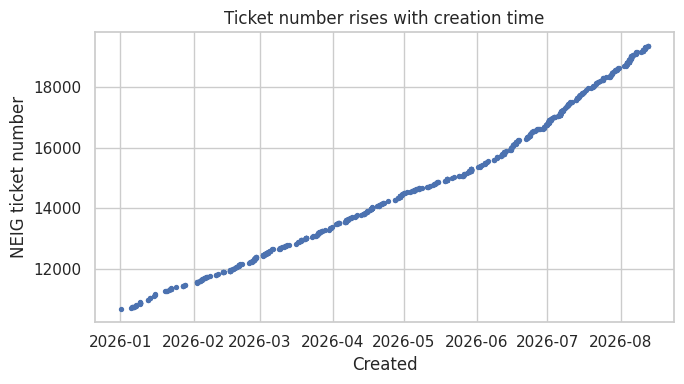

In [ ]:
tix['key_num'] = tix['Issue key'].str.extract(r'(\d+)').astype(int)
tix['created_dt'] = pd.to_datetime(tix['Created'], format='%d/%b/%y %I:%M %p')

created_as_number = tix['created_dt'].astype('int64')   
rho_created = tix['key_num'].corr(created_as_number, method='spearman')
rho_id = tix['key_num'].corr(tix['Issue id'], method='spearman')
print(f'Spearman(ticket number, Created)  = {rho_created:.7f}')
print(f'Spearman(ticket number, Issue id) = {rho_id:.7f}')
print('Created range:', tix.created_dt.min(), 'to', tix.created_dt.max())
print('Ticket-number range:', tix.key_num.min(), '-', tix.key_num.max(),
      '| slots:', tix.key_num.max() - tix.key_num.min() + 1, '| rows here:', len(tix))

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(tix.created_dt, tix.key_num, s=8)
ax.set(xlabel='Created', ylabel='NEIG ticket number', title='Ticket number rises with creation time')
plt.tight_layout(); plt.savefig('fig_task0_ticket_vs_created.png', dpi=150); plt.show()

In [ ]:
INTAKE_TYPES = ['New Profile', 'Connected Neighbor Profile', 'Flourishing Neighbor Profile']
tix['ticket_kind'] = np.where(tix['Issue Type'].isin(INTAKE_TYPES), 'intake (profile)', 'sub-ticket (care path etc.)')

intake_cols = ['Custom field (Housing Status)', 'Custom field (Eviction Status)', 'Custom field (Employment Status)']
chk = tix.groupby('ticket_kind')[['Parent'] + intake_cols].count()
chk['rows'] = tix.groupby('ticket_kind').size()
display(chk)
display(tix['Issue Type'].value_counts().to_frame('tickets'))

,Parent,Custom field (Housing Status),Custom field (Eviction Status),Custom field (Employment Status),rows
ticket_kind,,,,,
intake (profile),0,426,426,426,426
sub-ticket (care path etc.),213,0,0,0,213


,tickets
Issue Type,
New Profile,378
Rent Assistance Care Path,112
Connected Neighbor Profile,44
House Navigation Care Path,24
Basic Supplies,17
Utility Care Path,12
Other,9
Legal Assistance Care Path,7
Food Care Path,5


**Task 0 answer (draft, verify wording yourself):**
- `NEIG-#####` is the Jira issue counter for the whole board. It rises with `Issue id` (rank correlation 1.0) and with `Created` (about 0.9999997), so it is a creation-order sequence number, not a family or person ID.
- The numbers span 8,655 slots but this file holds 639 rows, so the counter is shared with tickets that are not in this population (other people, other issue types, other programs). That is why ticket numbers are not sequential per family.
- `Issue Type` separates the two kinds of rows: **426 intake (profile) tickets** (New Profile, Connected Neighbor Profile, Flourishing Neighbor Profile), which hold the case data, and **213 sub-tickets** (Rent Assistance Care Path, House Navigation, etc.), which always have a `Parent` ticket and none of the intake fields.
- Consequence: any share or average about families must use the 426 intake tickets, not all 639 rows.

## Task 1: Map the data to the partner plan (Figures 1 and 2)

In [4]:
intake = tix[tix['ticket_kind'] == 'intake (profile)'].copy()
H, E = 'Custom field (Housing Status)', 'Custom field (Eviction Status)'

evicted  = intake[E].eq('Currently being evicted')
notice7  = intake[E].eq('Received 7 day notice')
unhoused = intake[H].eq('Unhoused')
intake['eviction_risk'] = evicted | unhoused | (notice7 if COUNT_7DAY_AS_RISK else False)

print('Intake tickets (Reconnect):', len(intake))
print(' currently being evicted :', evicted.sum())
print(' unhoused                :', unhoused.sum(), '| both evicted and unhoused:', (evicted & unhoused).sum())
print(' 7-day notice            :', notice7.sum(), '(counted as risk)' if COUNT_7DAY_AS_RISK else '(not counted)')
print(' eviction-risk total     :', intake.eviction_risk.sum())
print(' housing-stable          :', (~intake.eviction_risk).sum())
print(' of which eviction status "Unknown":', intake.loc[~intake.eviction_risk, E].eq('Unknown').sum())

Intake tickets (Reconnect): 426
 currently being evicted : 106
 unhoused                : 15 | both evicted and unhoused: 1
 7-day notice            : 2 (counted as risk)
 eviction-risk total     : 122
 housing-stable          : 304
 of which eviction status "Unknown": 62


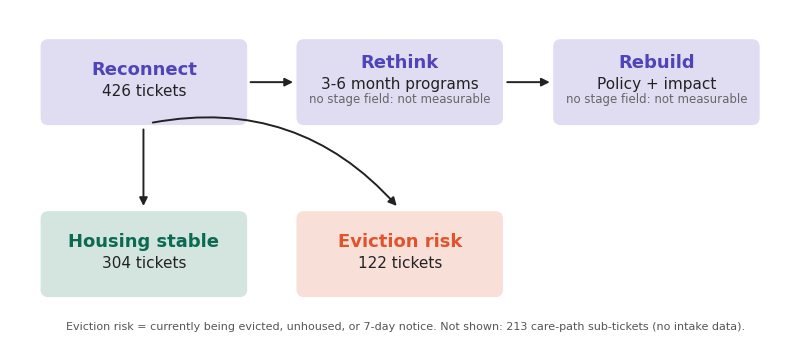

In [ ]:
n_int = len(intake); n_risk = int(intake.eviction_risk.sum()); n_stable = n_int - n_risk
n_sub = int((tix.ticket_kind != 'intake (profile)').sum())

# This cell I used AI to help make the picture look the same
fig, ax = plt.subplots(figsize=(10.2, 4.3))
ax.set_xlim(0, 930); ax.set_ylim(385, 0); ax.axis('off')
PURPLE, GREEN, RED = ('#e0ddf3', '#5045b8'), ('#d4e4df', '#0a6b52'), ('#f8e0d9', '#e0532b')
def box(x, y, title, lines, colors, w=241, h=98):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0,rounding_size=8', fc=colors[0], ec=colors[0], lw=1.2, alpha=1))
    n = len(lines); top = y + h/2 - 14 - (n-1)*8
    ax.text(x + w/2, top, title, ha='center', va='center', fontsize=13, fontweight='bold', color=colors[1])
    for i, (txt, size, col) in enumerate(lines):
        ax.text(x + w/2, top + 25 + i*17, txt, ha='center', va='center', fontsize=size, color=col)
box(37, 35, 'Reconnect', [(f'{n_int} tickets', 11, '#222')], PURPLE)
box(338, 35, 'Rethink', [('3-6 month programs', 11, '#222'), ('no stage field: not measurable', 8.5, '#666')], PURPLE)
box(640, 35, 'Rebuild', [('Policy + impact', 11, '#222'), ('no stage field: not measurable', 8.5, '#666')], PURPLE)
box(37, 235, 'Housing stable', [(f'{n_stable} tickets', 11, '#222')], GREEN)
box(338, 235, 'Eviction risk', [(f'{n_risk} tickets', 11, '#222')], RED)
arrow = dict(arrowstyle='-|>', color='#222', lw=1.4, shrinkA=0, shrinkB=0)
ax.annotate('', xy=(333, 84), xytext=(283, 84), arrowprops=arrow)
ax.annotate('', xy=(635, 84), xytext=(585, 84), arrowprops=arrow)
ax.annotate('', xy=(157, 228), xytext=(157, 139), arrowprops=arrow)
ax.annotate('', xy=(455, 228), xytext=(168, 131), arrowprops=dict(**arrow, connectionstyle='arc3,rad=-0.28'))
ax.text(465, 372, f'Eviction risk = currently being evicted, unhoused, or 7-day notice. Not shown: {n_sub} care-path sub-tickets (no intake data).',
        ha='center', fontsize=8, color='#555')
plt.savefig('fig1_stages.png', dpi=150, bbox_inches='tight'); plt.show()

In [6]:
tix_per_pid_all    = tix['PID'].value_counts()
tix_per_pid_intake = intake['PID'].value_counts()
counts = {'intake': tix_per_pid_intake, 'all': tix_per_pid_all}

def quad(base):
    d = intake.copy()
    d['chronic'] = d['PID'].map(counts[base]) >= 2
    return pd.crosstab(d.eviction_risk.map({True: 'urgent', False: 'not urgent'}),
                       d.chronic.map({True: 'chronic (2+)', False: 'episodic (1)'}), margins=True)

print('Figure 2 base =', PID_BASE); q = quad(PID_BASE); display(q)
other = 'all' if PID_BASE == 'intake' else 'intake'
print('Sensitivity: counting PID over', other, 'tickets instead'); display(quad(other))

Figure 2 base = all


chronic,chronic (2+),episodic (1),All
eviction_risk,,,
not urgent,149,155,304
urgent,32,90,122
All,181,245,426


Sensitivity: counting PID over intake tickets instead


chronic,chronic (2+),episodic (1),All
eviction_risk,,,
not urgent,44,260,304
urgent,14,108,122
All,58,368,426


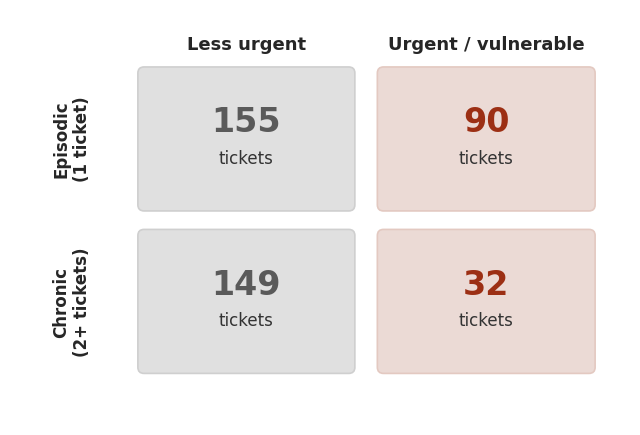

In [ ]:
d = intake.copy()
d['chronic'] = d['PID'].map(counts[PID_BASE]) >= 2

def cell(is_urgent, is_chronic):
    return int(((d.eviction_risk == is_urgent) & (d.chronic == is_chronic)).sum())

fig, ax = plt.subplots(figsize=(8, 5.4))
ax.set_xlim(0, 800); ax.set_ylim(540, 0); ax.axis('off')

GREY = ('#E0E0E0', '#CFCFCF', '#5A5A5A')     
PINK = ('#EBDAD5', '#E3C9C1', '#9C2F14')

def draw_box(x, y, w, h, colors, number):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0,rounding_size=8', fc=colors[0], ec=colors[1], lw=1.2))
    ax.text(x + w/2, y + h/2 - 22, str(number), ha='center', va='center', fontsize=24, fontweight='bold', color=colors[2])
    ax.text(x + w/2, y + h/2 + 25, 'tickets', ha='center', va='center', fontsize=12, color='#333333')


ax.text(305, 45, 'Less urgent', ha='center', va='center', fontsize=13, fontweight='bold')
ax.text(614, 45, 'Urgent / vulnerable', ha='center', va='center', fontsize=13, fontweight='bold')

ax.text(80, 168, 'Episodic\n(1 ticket)', ha='center', va='center', rotation=90, fontsize=12, fontweight='bold')
ax.text(80, 380, 'Chronic\n(2+ tickets)', ha='center', va='center', rotation=90, fontsize=12, fontweight='bold')

draw_box(165, 75, 280, 187, GREY, cell(False, False))    # less urgent + episodic
draw_box(474, 75, 281, 187, PINK, cell(True, False))     # urgent + episodic
draw_box(165, 286, 280, 187, GREY, cell(False, True))    # less urgent + chronic
draw_box(474, 286, 281, 187, PINK, cell(True, True))     # urgent + chronic

plt.savefig('fig2_segments.png', dpi=150, bbox_inches='tight'); plt.show()

### Column triage (all 93 columns)

In [ ]:
RULES = [  # (column-name prefix, class, reason). First match wins, so specific prefixes come first.
 ('PID Match Basis', 'Needed', 'Says how reliable each PID is (name+DOB vs name only); required caveat for repeat-contact work'),
 ('PID', 'Needed', 'Person key for repeat contact (Q4) and Figure 2; name-matched, not perfect'),
 ('Summary', 'Drop', 'Just the text "Person <PID>"; duplicates PID'),
 ('Issue key', 'Needed', 'Ticket ID; needed for Task 0 and for linking household members'),
 ('Issue id', 'Needed', 'Internal Jira ID, but needed to explain ticket-number ordering (Task 0)'),
 ('Issue Type', 'Needed', 'Separates intake profiles from sub-tickets'),
 ('Status Category Changed', 'Drop', 'Jira workflow timestamp; not about the family'),
 ('Status Category', 'Optional', 'Coarse workflow bucket (To Do / In Progress / Done); only for case-outcome context'),
 ('Status', 'Optional', 'Case workflow status (Referral Only, Duplicate, etc.); needed to flag duplicates in cleaning'),
 ('Resolution', 'Optional', 'Only 73 of 639 filled; describes closure, not need'),
 ('Reporter', 'Drop', 'Staff member who logged the ticket (Jira system field)'),
 ('Creator', 'Drop', 'Staff member who created the ticket (Jira system field)'),
 ('Created', 'Needed', 'Ticket creation time; timeline and first-vs-latest ticket ordering'),
 ('Updated', 'Optional', 'Last edit time; workflow, not need'),
 ('Resolved', 'Optional', 'Closure time; only 73 filled'),
 ('Labels', 'Optional', 'Free tags (SNAP, Workforce-Unemployed, ...) that may cross-check benefit and work fields'),
 ('Watchers', 'Drop', 'Staff following the ticket (Jira system field)'),
 ('# Additional Household Members', 'Needed', 'Household size for Q1 and Q3; also a check against the long file'),
 ('Custom field (City)', 'Optional', 'Location detail; ZIP is the better geographic key'),
 ('Custom field (Community Ministry)', 'Optional', 'Which SLCM ministry site handled the family'),
 ('Custom field (Court Date)', 'Optional', 'Only filled for eviction cases (69); supports urgency but sparse'),
 ('Custom field (Current Employer)', 'Drop', 'Free text with 205 unique values; identifying and not needed'),
 ('Age at Intake', 'Needed', 'Caregiver age for household description (Q3)'),
 ('Custom field (Employment Status)', 'Needed', 'Q2 core variable'),
 ('Custom field (Eviction Reason)', 'Optional', 'Why eviction is happening; only asked of some families'),
 ('Custom field (Eviction Status)', 'Needed', 'Q1 and Figures 1-2 core variable'),
 ('Custom field (Gender)', 'Optional', 'Demographic context'),
 ('Custom field (Goals)', 'Optional', 'Care-path goals the family chose; describes needs'),
 ('Custom field (Household Identities)', 'Optional', 'Household characteristics (e.g. pregnancy); context only'),
 ('Custom field (Household repairs required?)', 'Optional', 'Housing condition flag'),
 ('Custom field (Housing Status)', 'Needed', 'Q1 and Figures 1-2 core variable'),
 ('Custom field (Income Amount ($))', 'Needed', 'Q2 core variable'),
 ('Custom field (Insurance Provider for Family)', 'Optional', 'Coverage context'),
 ('Custom field (Intake Date)', 'Optional', 'Intake date typed by staff; compare with Created'),
 ('Custom field (Landlord Name)', 'Drop', 'Names another person; 309 unique free-text values; not needed'),
 ('Custom field (Loss of Income Causation)', 'Optional', 'Reason income fell; helps explain the Q2 mismatch'),
 ('Custom field (Main reason Neighbor stopped paying rent)', 'Optional', 'Cause of rent problems; supporting context'),
 ('Custom field (Monthly Rent ($))', 'Optional', 'Rent burden context; renters only'),
 ('Custom field (Other Professionals Detail)', 'Drop', 'Free text notes'),
 ('Custom field (Other professionals helping with goals?)', 'Optional', 'Yes/No support flag'),
 ('Custom field (Past Due Rent ($))', 'Optional', 'Severity of rent debt; renters only'),
 ('Custom field (People in Household 17 and Under)', 'Needed', 'Children count for Q3'),
 ('Custom field (People in Household 18+)', 'Needed', 'Adult count for Q3'),
 ('Custom field (People in Household 65+)', 'Optional', 'Yes/No flag for seniors'),
 ('Custom field (Preferred method of contact)', 'Drop', 'Staff outreach preference; not about need'),
 ('Custom field (Primary Insurance)', 'Optional', 'Coverage type context'),
 ('Custom field (Primary Language Spoken in Home)', 'Optional', 'Language context; messy free text (25 values)'),
 ('Custom field (Pronoun)', 'Drop', 'Redundant with Gender for this phase'),
 ('Custom field (Race/Ethnicity)', 'Optional', 'Demographic context; handle carefully'),
 ('Custom field (Rank)', 'Drop', 'Jira board sort order'),
 ('Custom field (Rent Intake Form Goals)', 'Optional', 'What renters said they want help with'),
 ('Custom field (Rent-to-Income %)', 'Optional', 'Derived rent burden; check against rent and income'),
 ('Custom field (Response Method)', 'Drop', 'How the family wants a reply; not about need'),
 ('Custom field (Section 8 or Housing Voucher)', 'Optional', 'Housing subsidy context'),
 ('Custom field (Source of income)', 'Needed', 'Q2 core variable'),
 ('Custom field (State)', 'Optional', 'Location detail; some non-KY values to check'),
 ('Custom field (Utility Past Due)', 'Optional', 'Utility strain; more relevant to Part 2 utility data'),
 ('Custom field (Zip Code)', 'Needed', 'Q1 geography'),
 ('Custom field ([CHART] Date of First Response)', 'Optional', 'Staff response timing; not family need'),
 ('Custom field ([CHART] Time in Status)', 'Drop', 'Encoded Jira status timing string'),
 ('Has LG&E Account on File', 'Drop', 'Utility linkage flag; utility data comes in Part 2'),
 ('Has Water Account on File', 'Drop', 'Utility linkage flag; utility data comes in Part 2'),
 ('Has Email on File', 'Drop', 'Contact-info flag, not need'),
 ('Has Phone on File', 'Drop', 'Contact-info flag, not need'),
 ('Comment', 'Drop', 'Staff free-text notes that may contain identifying details'),
 ('Parent summary', 'Drop', 'Text of the parent ticket title; appears to contain personal names, so do not use or display'),
 ('Parent key', 'Needed', 'Links each sub-ticket to its intake (Task 0)'),
 ('Parent', 'Needed', 'Numeric parent ID; identifies sub-tickets'),
]
def triage(col):
    for prefix, cls, why in RULES:
        if col.startswith(prefix):
            return cls, why
    return None, None


classes = []
reasons = []
for col in ORIG_COLS:
    cls, why = triage(col)
    classes.append(cls)
    reasons.append(why)
t = pd.DataFrame({'column': ORIG_COLS, 'class': classes, 'reason': reasons})
t['dtype'] = tix[ORIG_COLS].dtypes.astype(str).values
t['non_null'] = tix[ORIG_COLS].notna().sum().values
t['pct_missing_all_639'] = (100 * (1 - t.non_null / len(tix))).round(1)
t['pct_missing_intakes_426'] = (100 * (1 - intake[ORIG_COLS].notna().sum().values / len(intake))).round(1)
assert t['class'].notna().all(), t[t['class'].isna()]
print(len(t), 'columns triaged'); display(t['class'].value_counts().to_frame('columns'))
t.to_csv('column_triage.csv', index=False)
display(t)

93 columns triaged


,columns
class,
Optional,46
Drop,28
Needed,19


,column,class,reason,dtype,non_null,pct_missing_all_639,pct_missing_intakes_426
0,PID,Needed,Person key for repeat contact (Q4) and Figure ...,str,639,0.0,0.0
1,PID Match Basis,Needed,Says how reliable each PID is (name+DOB vs nam...,str,639,0.0,0.0
2,Summary,Drop,"Just the text ""Person <PID>""; duplicates PID",str,639,0.0,0.0
3,Issue key,Needed,Ticket ID; needed for Task 0 and for linking h...,str,639,0.0,0.0
4,Issue id,Needed,"Internal Jira ID, but needed to explain ticket...",int64,639,0.0,0.0
5,Issue Type,Needed,Separates intake profiles from sub-tickets,str,639,0.0,0.0
6,Status,Optional,"Case workflow status (Referral Only, Duplicate...",str,639,0.0,0.0
7,Resolution,Optional,"Only 73 of 639 filled; describes closure, not ...",str,73,88.6,99.5
8,Reporter,Drop,Staff member who logged the ticket (Jira syste...,str,639,0.0,0.0
9,Reporter Id,Drop,Staff member who logged the ticket (Jira syste...,str,639,0.0,0.0


### Parts of the partner plan the data does not currently support
- **Rethink and Rebuild stages:** no field records program enrollment, program length, or a policy/long-term status. Only Reconnect (intake) is measurable. Proposal: add a required `Program stage` field and `Stage entered date`, plus an outcome field when a case closes.
- **Urgency and duration are proxies:** urgency is inferred from eviction/housing status and duration from name-matched PID counts. Proposal: record an explicit urgency level and a stable person ID assigned at intake.
- **Outcomes:** Status mixes workflow steps (Referral Only, Duplicate) with results (Goal Attained). Proposal: separate workflow status from outcome.
- **Unknowns in the key field:** eviction status is "Unknown" for many intakes. Proposal: make it required, with an explicit follow-up flag.

## Task 2: Summarize, clean, and answer

### 2.1 Summary of both files and data dictionary

In [ ]:
print('cleaned_intakes_masked.csv:', tix[ORIG_COLS].shape, '| intake tickets:', len(intake), '| sub-tickets:', len(tix) - len(intake))
print('household_members_long_v2.csv:', hh.shape, '| intakes covered:', hh['Issue key'].nunique(), 'of', len(intake))
print('\nIntake-file dtypes:'); display(tix[ORIG_COLS].dtypes.astype(str).value_counts().to_frame('columns'))

dd = t[t['class'].isin(['Needed', 'Optional'])][['column', 'class', 'dtype', 'reason', 'pct_missing_intakes_426']].copy()
n_unique = []
most_common = []
for c in dd['column']:
    n_unique.append(intake[c].nunique())                     
    if intake[c].notna().any():
        most_common.append(intake[c].mode().iloc[0])         
    else:
        most_common.append(None)                            
dd['n_unique_intakes'] = n_unique
dd['most_common_value'] = most_common
dd = dd.rename(columns={'reason': 'why_kept'})
dd.to_csv('data_dictionary_intakes.csv', index=False)
print(f'\nData dictionary (Needed + Optional): {len(dd)} of {len(t)} columns kept'); display(dd)

hh_dict = pd.DataFrame([
 ('PID', 'Person key (name-matched) of the primary contact'),
 ('Member ID', 'PID plus member number, unique per additional household member'),
 ('Issue key', 'Intake ticket the member belongs to (join key to the intake file)'),
 ('Member #', 'Order of the member within the ticket'),
 ('Age', 'Member age in years (0 = under 1); some values invalid, see cleaning log'),
 ('Gender', 'Member gender (Male/Female or missing)'),
 ('Race/Ethnicity', 'Free text, very sparse'),
 ('Relationship', 'Relationship to the primary contact (Son, Daughter, Spouse ...), often missing')],
 columns=['column', 'meaning'])
hh_dict['dtype'] = hh.dtypes.astype(str).values
hh_dict['pct_missing'] = (100 * hh.isna().mean()).round(1).values
hh_dict.to_csv('data_dictionary_household.csv', index=False); display(hh_dict)

cleaned_intakes_masked.csv: (639, 93) | intake tickets: 426 | sub-tickets: 213
household_members_long_v2.csv: (993, 8) | intakes covered: 400 of 426

Intake-file dtypes:


,columns
str,85
float64,6
int64,2



Data dictionary (Needed + Optional): 65 of 93 columns kept


,column,class,dtype,why_kept,pct_missing_intakes_426,n_unique_intakes,most_common_value
0,PID,Needed,str,Person key for repeat contact (Q4) and Figure ...,0.0,395,P0101
1,PID Match Basis,Needed,str,Says how reliable each PID is (name+DOB vs nam...,0.0,1,Name + DOB
3,Issue key,Needed,str,Ticket ID; needed for Task 0 and for linking h...,0.0,426,NEIG-10695
4,Issue id,Needed,int64,"Internal Jira ID, but needed to explain ticket...",0.0,426,35312
5,Issue Type,Needed,str,Separates intake profiles from sub-tickets,0.0,3,New Profile
6,Status,Optional,str,"Case workflow status (Referral Only, Duplicate...",0.0,10,Referral Only
7,Resolution,Optional,str,"Only 73 of 639 filled; describes closure, not ...",99.5,1,Won't Do
12,Created,Needed,str,Ticket creation time; timeline and first-vs-la...,0.0,424,09/Jul/26 1:14 PM
13,Updated,Optional,str,"Last edit time; workflow, not need",0.0,382,28/Jul/26 2:42 PM
14,Resolved,Optional,str,Closure time; only 73 filled,99.5,2,02/Mar/26 12:45 PM


,column,meaning,dtype,pct_missing
0,PID,Person key (name-matched) of the primary contact,str,0.0
1,Member ID,"PID plus member number, unique per additional ...",str,0.0
2,Issue key,Intake ticket the member belongs to (join key ...,str,0.0
3,Member #,Order of the member within the ticket,int64,0.0
4,Age,Member age in years (0 = under 1); some values...,float64,9.4
5,Gender,Member gender (Male/Female or missing),str,34.7
6,Race/Ethnicity,"Free text, very sparse",str,60.9
7,Relationship,"Relationship to the primary contact (Son, Daug...",str,36.4


### 2.2 Cleaning (every decision is logged)

In [ ]:
df = intake.copy()
log = []
def note(step, column, n, decision, reason):
    log.append(dict(step=step, column=column, rows_affected=int(n), decision=decision, reason=reason))

# 1. Duplicates: flag, do not delete
df['is_duplicate'] = df['Status'].eq('Duplicate')
note('Flag duplicates', 'Status', df.is_duplicate.sum(), 'Flagged as is_duplicate; kept in all counts; sensitivity run in Q1',
     'Staff marked these as duplicates but deleting them would silently change Figures 1-2')

# 2. State spelling
S = 'Custom field (State)'
df['state_clean'] = df[S].str.strip().str.upper().replace({'KENTUCKY': 'KY'})
note('Standardize state', S, (df[S].fillna('') != df['state_clean'].fillna('')).sum(), 'Trim, upper-case, Kentucky -> KY',
     'Same state typed many ways (KY, Ky, ky, Kentucky, ...)')

# 3. ZIP+4
Z = 'Custom field (Zip Code)'
df['zip5'] = df[Z].astype('string').str.extract(r'(\d{5})')[0]
note('ZIP to 5 digits', Z, (df[Z].notna() & (df[Z].astype('string').str.len() > 5)).sum(), 'Keep first 5 digits', 'ZIP+4 values would split one ZIP into many groups')

# 4. Caregiver age
df['age_clean'] = df['Age at Intake'].where(df['Age at Intake'].between(15, 100))
note('Impossible caregiver age', 'Age at Intake', (df['Age at Intake'].notna() & df.age_clean.isna()).sum(), 'Set to missing (outside 15-100)', 'Negative or implausible ages are entry errors')

# 5. Household counts stored as text with a top-code
P = 'Custom field (People in Household '
# Children count
kids_col = P + '17 and Under)'
df['n_kids_topcoded'] = df[kids_col] == 'More than 5'                       
df['n_kids'] = pd.to_numeric(df[kids_col].replace({'More than 5': '6'}), errors='coerce')
note('Text to number', kids_col, df.n_kids_topcoded.sum(), '"More than 5" -> 6 and flagged (true value is 6 or more)', 'Column is text; top-coded values are lower bounds')

# Adult count (same idea)
adults_col = P + '18+)'
df['n_adults_topcoded'] = df[adults_col] == 'More than 5'
df['n_adults'] = pd.to_numeric(df[adults_col].replace({'More than 5': '6'}), errors='coerce')
note('Text to number', adults_col, df.n_adults_topcoded.sum(), '"More than 5" -> 6 and flagged (true value is 6 or more)', 'Column is text; top-coded values are lower bounds')

# 6. Household size
df['hh_size'] = df['# Additional Household Members'] + 1
note('Household size', '# Additional Household Members', len(df), 'hh_size = additional members + 1 (the primary contact)', 'The column excludes the person who contacted SLCM')

# 7. Rent outliers: keep all rent data, flag the extreme values
R, PD = 'Custom field (Monthly Rent ($))', 'Custom field (Past Due Rent ($))'
df['rent_clean'] = df[R]                                   
df['pastdue_clean'] = df[PD]
df['rent_high_flag'] = df[R] > 5000
df['pastdue_high_flag'] = df[PD] > 50000
note('Rent outliers flagged', R, df.rent_high_flag.sum(), 'Kept as entered and flagged (>$5,000); medians used instead of means', 'A value like $125,100 may be a typo, but we cannot verify it, so we do not change it')
note('Past-due outliers flagged', PD, df.pastdue_high_flag.sum(), 'Kept as entered and flagged (>$50,000); medians used instead of means', 'A value like $242,682 may be a typo, but we cannot verify it, so we do not change it')

# 8. Income: keep but flag
I = 'Custom field (Income Amount ($))'
df['income'] = df[I]; df['income_high_flag'] = df[I] > 10000
note('High income flag', I, df.income_high_flag.sum(), 'Kept, flagged (>$10,000); medians used instead of means', 'Could be real or an annual figure entered as monthly; cannot verify')

# 9. Household-member file
hh_c = hh.copy(); hh_c['age_clean'] = hh_c['Age'].where(hh_c['Age'].between(0, 100))
note('Impossible member age', 'household_members Age', (hh_c.Age.notna() & hh_c.age_clean.isna()).sum(), 'Set to missing (outside 0-100)', 'Negative ages and values like 1824 are entry errors')
note('Missing member age', 'household_members Age', hh_c.Age.isna().sum(), 'Left missing; age summaries use known ages only', 'Cannot be recovered')

cleaning_log = pd.DataFrame(log); cleaning_log.to_csv('cleaning_log.csv', index=False)
display(cleaning_log)

# Consistency checks worth documenting
members_in_long_file = hh.groupby('Issue key').size()                    
expected = df['Issue key'].map(members_in_long_file).fillna(0)         
chk_n = (df['# Additional Household Members'] == expected).mean()
print(f'Additional-member count agrees with long file for {chk_n:.1%} of intakes')
print(f'hh_size equals adults + children for {(df.hh_size == df.n_kids + df.n_adults).mean():.1%} of intakes (both fields present: {df[["n_kids","n_adults"]].notna().all(axis=1).sum()})')

,step,column,rows_affected,decision,reason
0,Flag duplicates,Status,12,Flagged as is_duplicate; kept in all counts; s...,Staff marked these as duplicates but deleting ...
1,Standardize state,Custom field (State),226,"Trim, upper-case, Kentucky -> KY","Same state typed many ways (KY, Ky, ky, Kentuc..."
2,ZIP to 5 digits,Custom field (Zip Code),5,Keep first 5 digits,ZIP+4 values would split one ZIP into many groups
3,Impossible caregiver age,Age at Intake,4,Set to missing (outside 15-100),Negative or implausible ages are entry errors
4,Text to number,Custom field (People in Household 17 and Under),15,"""More than 5"" -> 6 and flagged (true value is ...",Column is text; top-coded values are lower bounds
5,Text to number,Custom field (People in Household 18+),6,"""More than 5"" -> 6 and flagged (true value is ...",Column is text; top-coded values are lower bounds
6,Household size,# Additional Household Members,426,hh_size = additional members + 1 (the primary ...,The column excludes the person who contacted SLCM
7,Rent outliers flagged,Custom field (Monthly Rent ($)),1,"Kept as entered and flagged (>$5,000); medians...","A value like $125,100 may be a typo, but we ca..."
8,Past-due outliers flagged,Custom field (Past Due Rent ($)),1,"Kept as entered and flagged (>$50,000); median...","A value like $242,682 may be a typo, but we ca..."
9,High income flag,Custom field (Income Amount ($)),6,"Kept, flagged (>$10,000); medians used instead...",Could be real or an annual figure entered as m...


Additional-member count agrees with long file for 100.0% of intakes
hh_size equals adults + children for 56.1% of intakes (both fields present: 426)


### 2.3 Question 1: Housing crisis severity

Eviction-risk share: 122 of 426 = 28.6%
Excluding 12 flagged duplicates: 119 of 414 = 28.7%
Eviction status breakdown:


,share
Custom field (Eviction Status),
Not being evicted,0.599
Currently being evicted,0.249
Unknown,0.148
Received 7 day notice,0.005


Housing status breakdown:


,tickets
Custom field (Housing Status),
Rent- past due,234
Rent - nothing past due,126
Staying with friends/family,29
Unhoused,15
Other,10
Own home - nothing past due,5
Own home - mortgage past due,4
Staying at extended stay hotel or short-term housing,3



ZIPs with 15+ tickets: 9 (covering 331 tickets); chi-square p = 0.003


,n,at_risk,share
zip5,,,
40212,15,8,0.533
40203,17,8,0.471
40210,16,7,0.438
40216,30,9,0.300
40219,18,5,0.278
40214,102,21,0.206
40118,17,3,0.176
40215,89,14,0.157
40208,27,3,0.111


By household size; chi-square p = 0.443


,n,at_risk,share
hh_bin,,,
1-2,167,42,0.251
3,85,26,0.306
4,90,26,0.289
5,46,18,0.391
6+,38,10,0.263


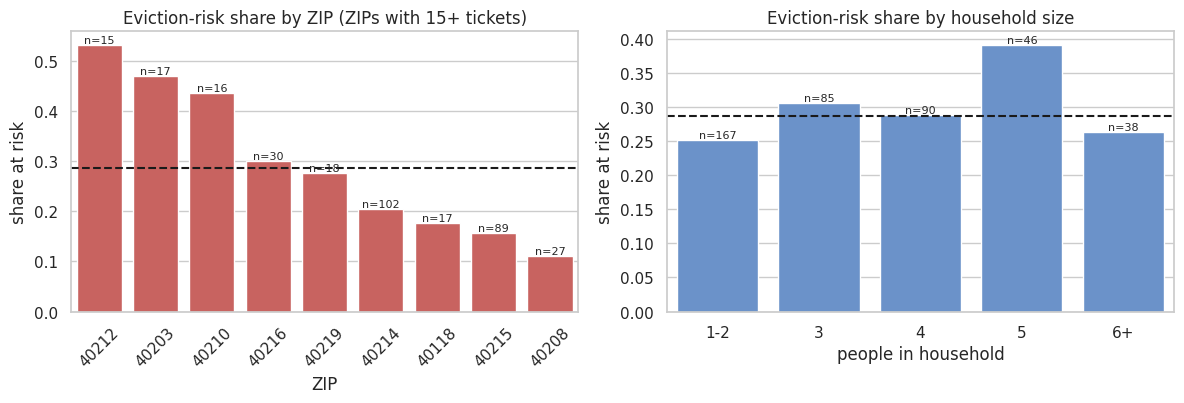

In [ ]:
from scipy.stats import chi2_contingency
H, E = 'Custom field (Housing Status)', 'Custom field (Eviction Status)'
d = df.copy()
share = d.eviction_risk.mean()
print(f'Eviction-risk share: {d.eviction_risk.sum()} of {len(d)} = {share:.1%}')
nd = d[~d.is_duplicate]; print(f'Excluding {d.is_duplicate.sum()} flagged duplicates: {nd.eviction_risk.sum()} of {len(nd)} = {nd.eviction_risk.mean():.1%}')
print('Eviction status breakdown:'); display(d[E].value_counts(normalize=True).round(3).to_frame('share'))
print('Housing status breakdown:'); display(d[H].value_counts().to_frame('tickets'))

gz = d.groupby('zip5').eviction_risk.agg(n='size', at_risk='sum', share='mean')
gz_big = gz[gz.n >= 15].sort_values('share', ascending=False)
big_zip_rows = d[d.zip5.isin(gz_big.index)]                              
chi_z = chi2_contingency(pd.crosstab(big_zip_rows.zip5, big_zip_rows.eviction_risk))
print(f'\nZIPs with 15+ tickets: {len(gz_big)} (covering {gz_big.n.sum()} tickets); chi-square p = {chi_z[1]:.3f}'); display(gz_big.round(3))

d['hh_bin'] = pd.cut(d.hh_size, [0, 2, 3, 4, 5, 50], labels=['1-2', '3', '4', '5', '6+'])
gh = d.groupby('hh_bin', observed=True).eviction_risk.agg(n='size', at_risk='sum', share='mean')
chi_h = chi2_contingency(pd.crosstab(d.hh_bin, d.eviction_risk))
print(f'By household size; chi-square p = {chi_h[1]:.3f}'); display(gh.round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sns.barplot(x=gz_big.index, y=gz_big['share'], ax=ax[0], color='#d9534f'); ax[0].axhline(share, ls='--', c='k')
ax[0].bar_label(ax[0].containers[0], labels=[f'n={n}' for n in gz_big['n']], fontsize=8)   
ax[0].set(title='Eviction-risk share by ZIP (ZIPs with 15+ tickets)', xlabel='ZIP', ylabel='share at risk'); ax[0].tick_params(axis='x', rotation=45)
sns.barplot(x=gh.index.astype(str), y=gh['share'], ax=ax[1], color='#5b8fd9'); ax[1].axhline(share, ls='--', c='k')
ax[1].bar_label(ax[1].containers[0], labels=[f'n={n}' for n in gh['n']], fontsize=8)
ax[1].set(title='Eviction-risk share by household size', xlabel='people in household', ylabel='share at risk')
plt.tight_layout(); plt.savefig('q1_housing.png', dpi=150); plt.show()

### 2.4 Question 2: Employment vs. income

Employment "Other" / missing (excluded from the comparison): 29 of 426


,n,median,mean,pct_zero
emp_group,,,,
Employed,175,2000.0,2988.1,4.6
Unemployed,222,0.0,740.0,54.1


Mann-Whitney U p = 3.8e-38 (income differs between groups?)
Primary source of income (% within group):


Custom field (Source of income),Food benefits - TANF/SNAP,Full-time employment,Missing,No income,Other,Part-time employment,Pension,Social Security - SSI/SSDI
emp_group,,,,,,,,
Employed,30.9,43.4,0.0,1.1,4.6,20.0,0.0,0.0
Unemployed,50.0,4.1,1.4,32.0,2.7,1.4,0.5,8.1


Hardship outcomes by employment group (does employment predict hardship?):


,eviction_risk,rent_past_due,n,median_past_due_amt,median_rent_to_income
emp_group,,,,,
Employed,0.331,0.600,175,1958.500,52.457
Unemployed,0.252,0.514,222,1887.315,120.724


Eviction risk vs employment group: chi-square p = 0.105
Eviction risk by income band:


,n,share
income_band,,
$0,128,0.273
"$1-1,000",96,0.240
"$1,001-2,000",80,0.288
">$2,000",93,0.355


Employed households with zero or "No income" as primary source: 8 zero-income of 175


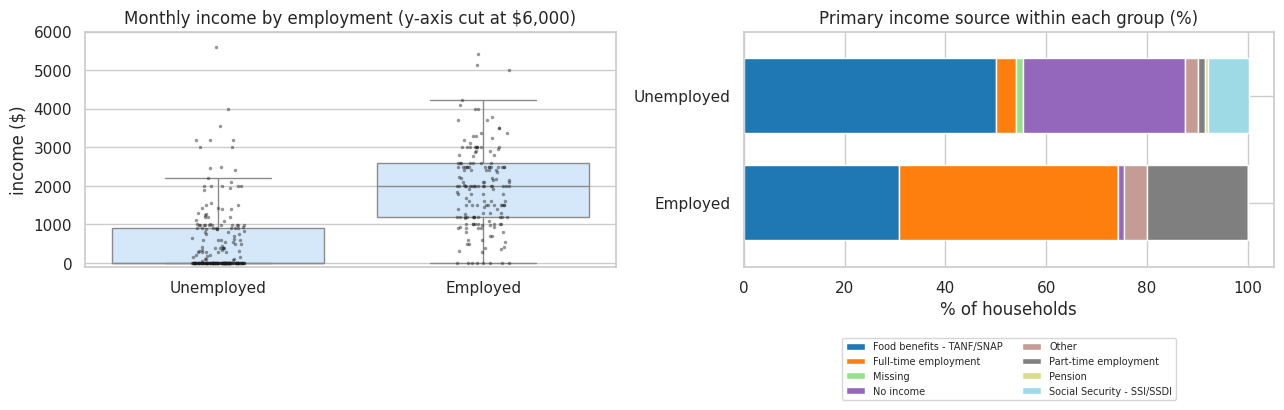

In [ ]:
EMP, SRC = 'Custom field (Employment Status)', 'Custom field (Source of income)'
emp_map = {'Employed': 'Employed', 'Employed, but need more hours and/or different work': 'Employed',
           'Unemployed but want to find work': 'Unemployed', 'Unemployed and not looking for work': 'Unemployed'}
d = df.copy(); d['emp_group'] = d[EMP].map(emp_map)
print('Employment "Other" / missing (excluded from the comparison):', d.emp_group.isna().sum(), 'of', len(d))
d2 = d.dropna(subset=['emp_group', 'income']).copy()

d2['is_zero'] = d2.income == 0                                            
summ = d2.groupby('emp_group').income.agg(['size', 'median', 'mean'])
summ = summ.rename(columns={'size': 'n'})
summ['pct_zero'] = d2.groupby('emp_group')['is_zero'].mean() * 100
summ = summ.round(1)
display(summ)
from scipy.stats import mannwhitneyu
u = mannwhitneyu(d2[d2.emp_group == 'Employed'].income, d2[d2.emp_group == 'Unemployed'].income)
print(f'Mann-Whitney U p = {u.pvalue:.2g} (income differs between groups?)')
src_ct = pd.crosstab(d2.emp_group, d2[SRC].fillna('Missing'), normalize='index').round(3) * 100
print('Primary source of income (% within group):'); display(src_ct)
d2['rent_past_due'] = d2[H] == 'Rent- past due'                          
hard = d2.groupby('emp_group')[['eviction_risk', 'rent_past_due']].mean().round(3)   
hard['n'] = d2.groupby('emp_group').size()
hard['median_past_due_amt'] = d2.groupby('emp_group')['pastdue_clean'].median()
hard['median_rent_to_income'] = d2.groupby('emp_group')['Custom field (Rent-to-Income %)'].median().round(3)
print('Hardship outcomes by employment group (does employment predict hardship?):'); display(hard)
chi_e = chi2_contingency(pd.crosstab(d2.emp_group, d2.eviction_risk)); print(f'Eviction risk vs employment group: chi-square p = {chi_e[1]:.3f}')
d3 = d2[d2.income.notna()].copy(); d3['income_band'] = pd.cut(d3.income, [-1, 0, 1000, 2000, 1e9], labels=['$0', '$1-1,000', '$1,001-2,000', '>$2,000'])
band = d3.groupby('income_band', observed=True).eviction_risk.agg(n='size', share='mean').round(3); print('Eviction risk by income band:'); display(band)
print('Employed households with zero or "No income" as primary source:', ((d2.emp_group == 'Employed') & (d2.income == 0)).sum(), 'zero-income of', (d2.emp_group == 'Employed').sum())

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
sns.boxplot(data=d2, x='emp_group', y='income', ax=ax[0], showfliers=False, color='#cfe8ff')
sns.stripplot(data=d2, x='emp_group', y='income', ax=ax[0], size=2.5, alpha=.45, color='k')
ax[0].set_ylim(-100, 6000); ax[0].set(title='Monthly income by employment (y-axis cut at $6,000)', xlabel='', ylabel='income ($)')
src_ct.plot(kind='barh', stacked=True, ax=ax[1], colormap='tab20', width=.7)
ax[1].set(title='Primary income source within each group (%)', xlabel='% of households', ylabel='')
ax[1].legend(fontsize=7, loc='upper center', bbox_to_anchor=(.5, -.28), ncol=2)
plt.tight_layout(); plt.savefig('q2_employment_income.png', dpi=150, bbox_inches='tight'); plt.show()

### 2.5 Question 3: Household composition

Household size (primary contact + additional members):


,count,mean,std,min,25%,50%,75%,max
hh_size,426.0,3.33,1.63,1.0,2.0,3.0,4.0,9.0


Household size distribution (%):


,%
hh_size,
1,6.1
2,33.1
3,20.0
4,21.1
5,10.8
6,4.7
7,1.2
8,1.4
9,1.6


Children (17 and under), from intake field; 6 = "More than 5":


...

Adults (18+):


,%
n_adults,
0,7.7
1,59.2
2,19.0
3,6.3
4,4.2
5,2.1
6,1.4


Primary contact age: median 30, IQR 26-35

Additional members: 993 total, 891 with a valid age
Age of additional members: median 6; under 6: 49.6%; 6-17: 36.0%; 18+: 14.4%
Intakes whose long-file members include a child under 6: 304 of 360 intakes with known ages (84.4%)
Relationships (top):


,members
Relationship,
Missing,361
Son,314
Daughter,248
Spouse,10
Husband,7
Grandson,6
Mother,6
Boyfriend,4
Fiancé,3


Members per intake in long file: {'count': 400.0, 'mean': 2.48, 'std': 1.57, 'min': 1.0, '25%': 1.0, '50%': 2.0, '75%': 3.0, 'max': 8.0}


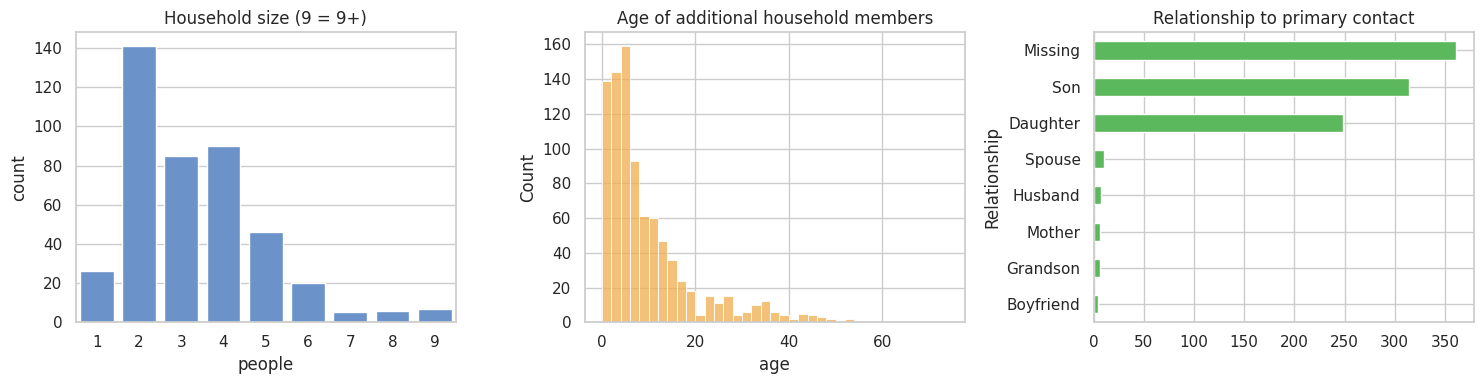

In [ ]:
d = df.copy()
print('Household size (primary contact + additional members):'); display(d.hh_size.describe().round(2).to_frame('hh_size').T)
print('Household size distribution (%):'); display((d.hh_size.value_counts(normalize=True).sort_index() * 100).round(1).to_frame('%'))
print('Children (17 and under), from intake field; 6 = "More than 5":'); display((d.n_kids.value_counts(normalize=True).sort_index() * 100).round(1).to_frame('%'))
print('Adults (18+):'); display((d.n_adults.value_counts(normalize=True).sort_index() * 100).round(1).to_frame('%'))
print(f'Primary contact age: median {d.age_clean.median():.0f}, IQR {d.age_clean.quantile(.25):.0f}-{d.age_clean.quantile(.75):.0f}')

m = hh_c.merge(d[['Issue key']], on='Issue key')
known = m.dropna(subset=['age_clean'])
print(f'\nAdditional members: {len(m)} total, {len(known)} with a valid age')
print(f"Age of additional members: median {known.age_clean.median():.0f}; under 6: {(known.age_clean < 6).mean():.1%}; 6-17: {known.age_clean.between(6, 17).mean():.1%}; 18+: {(known.age_clean >= 18).mean():.1%}")
known = known.copy()
known['under6'] = known.age_clean < 6                                   
per = known.groupby('Issue key')['under6'].any()                        
print(f'Intakes whose long-file members include a child under 6: {per.sum()} of {len(per)} intakes with known ages ({per.mean():.1%})')
print('Relationships (top):'); display(m.Relationship.fillna('Missing').value_counts().head(10).to_frame('members'))
print('Members per intake in long file:', m.groupby('Issue key').size().describe().round(2).to_dict())

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x=d.hh_size.clip(upper=9), ax=ax[0], color='#5b8fd9'); ax[0].set(title='Household size (9 = 9+)', xlabel='people')
sns.histplot(known.age_clean, bins=range(0, 75, 2), ax=ax[1], color='#f0ad4e'); ax[1].set(title='Age of additional household members', xlabel='age')
m.Relationship.fillna('Missing').value_counts().head(8).sort_values().plot(kind='barh', ax=ax[2], color='#5cb85c'); ax[2].set(title='Relationship to primary contact')
plt.tight_layout(); plt.savefig('q3_household.png', dpi=150); plt.show()

### 2.6 Question 4: Repeat contact

ANY ticket type: 150 of 439 people (34.2%) appear on 2+ of the 639 tickets
Tickets per PID (all tickets):


,PIDs
1,289
2,109
3,34
4,6
6,1


INTAKE tickets only: 27 of 395 people (6.8%) appear on 2+ intake tickets
Tickets per PID (intake tickets only):


,PIDs
1,368
2,24
3,2
4,1


Excluding tickets marked Duplicate: 21 of 389 people have 2+ intake tickets
Repeat people who have a ticket marked Duplicate: 6 of 27

Days between first and latest ticket: {'count': 27.0, 'mean': 62.0, 'std': 48.0, 'min': 0.0, '25%': 28.0, '50%': 56.0, '75%': 90.0, 'max': 181.0}
Eviction-risk: first vs latest ticket


...

Housing status text changed for 18.5% of repeat PIDs; eviction status text changed for 29.6%
Most common housing-status changes:


PIDs
housing_first               housing_last                 
Rent - nothing past due     Rent- past due              2
Rent- past due              Rent - nothing past due     1
Staying with friends/family Rent - nothing past due     1
                            Rent- past due              1

Most common eviction-status changes:


,,PIDs
evict_first,evict_last,
Unknown,Not being evicted,3
Currently being evicted,Not being evicted,2
Unknown,Currently being evicted,2
Not being evicted,Currently being evicted,1



All intake tickets are matched on Name + DOB (100%); the name-only matches are all care-path sub-tickets, so PID reliability is a smaller concern for this question than for the full file
Repeat PIDs whose first and latest intake are on the same day (likely double entry): 1 of 27
Repeat PIDs whose first and latest intake are within a week of each other: 4 of 27
Risk changed between first and latest ticket for 5 of 27 repeat PIDs


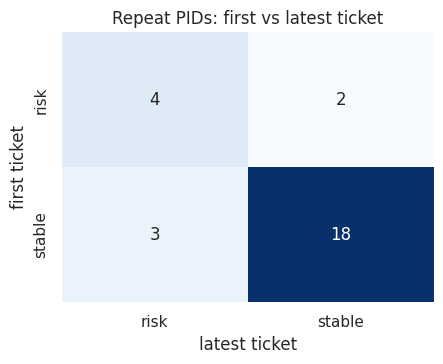

In [ ]:
d = df.sort_values('created_dt').copy()          

n_all = tix.groupby('PID').size()
print(f'ANY ticket type: {int((n_all >= 2).sum())} of {tix.PID.nunique()} people ({(n_all >= 2).mean():.1%}) appear on 2+ of the 639 tickets')
print('Tickets per PID (all tickets):'); display(n_all.value_counts().sort_index().to_frame('PIDs'))


n_per = d.groupby('PID').size()
rep_ids = n_per[n_per >= 2].index
print(f'INTAKE tickets only: {len(rep_ids)} of {d.PID.nunique()} people ({len(rep_ids)/d.PID.nunique():.1%}) appear on 2+ intake tickets')
print('Tickets per PID (intake tickets only):'); display(n_per.value_counts().sort_index().to_frame('PIDs'))

n_nodup = d[~d.is_duplicate].groupby('PID').size()
dup_people = set(d[d.is_duplicate].PID)
print(f'Excluding tickets marked Duplicate: {int((n_nodup >= 2).sum())} of {len(n_nodup)} people have 2+ intake tickets')
print(f'Repeat people who have a ticket marked Duplicate: {len(set(rep_ids) & dup_people)} of {len(rep_ids)}')

rep = d[d.PID.isin(rep_ids)]
first, last = rep.groupby('PID').first(), rep.groupby('PID').last()
cmp = pd.DataFrame(index=first.index)                                 
cmp['housing_first'] = first[H]
cmp['housing_last'] = last[H]
cmp['evict_first'] = first[E]
cmp['evict_last'] = last[E]
cmp['risk_first'] = first.eviction_risk
cmp['risk_last'] = last.eviction_risk
cmp['days_between'] = (last.created_dt - first.created_dt).dt.days
cmp['risk_first_label'] = cmp.risk_first.map({True: 'risk', False: 'stable'})  
cmp['risk_last_label'] = cmp.risk_last.map({True: 'risk', False: 'stable'})
print('\nDays between first and latest ticket:', cmp.days_between.describe().round(0).to_dict())
tr = pd.crosstab(cmp.risk_first_label, cmp.risk_last_label, margins=True, rownames=['first ticket'], colnames=['latest ticket'])
print('Eviction-risk: first vs latest ticket'); display(tr)
print(f'Housing status text changed for {(cmp.housing_first != cmp.housing_last).mean():.1%} of repeat PIDs; eviction status text changed for {(cmp.evict_first != cmp.evict_last).mean():.1%}')
print('Most common housing-status changes:'); display(cmp[cmp.housing_first != cmp.housing_last].groupby(['housing_first', 'housing_last']).size().sort_values(ascending=False).head(6).to_frame('PIDs'))
print('Most common eviction-status changes:'); display(cmp[cmp.evict_first != cmp.evict_last].groupby(['evict_first', 'evict_last']).size().sort_values(ascending=False).head(6).to_frame('PIDs'))
print(f"\nAll intake tickets are matched on Name + DOB ({(d['PID Match Basis'] == 'Name + DOB').mean():.0%}); the name-only matches are all care-path sub-tickets, so PID reliability is a smaller concern for this question than for the full file")
print(f'Repeat PIDs whose first and latest intake are on the same day (likely double entry): {(cmp.days_between == 0).sum()} of {len(cmp)}')
print(f'Repeat PIDs whose first and latest intake are within a week of each other: {(cmp.days_between < 7).sum()} of {len(cmp)}')
print(f'Risk changed between first and latest ticket for {(cmp.risk_first != cmp.risk_last).sum()} of {len(cmp)} repeat PIDs')

fig, ax = plt.subplots(figsize=(4.6, 3.8))
sns.heatmap(pd.crosstab(cmp.risk_first_label, cmp.risk_last_label), annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set(title='Repeat PIDs: first vs latest ticket', xlabel='latest ticket', ylabel='first ticket'); plt.tight_layout(); plt.savefig('q4_repeat.png', dpi=150); plt.show()

### 2.7 Question 5: Data quality issues

In [ ]:
sub_tix = tix[tix['ticket_kind'] != 'intake (profile)']
parent_pid = sub_tix['Parent key'].map(tix.set_index('Issue key')['PID'])     
has_parent = parent_pid.notna()
n_with_parent = int(has_parent.sum())
n_pid_mismatch = int((parent_pid[has_parent] != sub_tix.loc[has_parent, 'PID']).sum())
n_sub_only = len(set(sub_tix.PID) - set(df.PID))                              

chk = pd.DataFrame([
 ('Inconsistent text entry', 'Custom field (State)', f"{df[S].nunique()} spellings of one state (KY, Ky, Kentucky, ...)", 'Standardized to KY (cleaning step 2)', 'Free-text entry with no dropdown; grouping would otherwise fail'),
 ('Impossible values', 'Age at Intake; household Age', f"caregiver ages < 15: {(df['Age at Intake'] < 15).sum()}; member ages outside 0-100: {(hh.Age.notna() & ~hh.Age.between(0, 100)).sum()} (min {hh.Age.min():.0f}, max {hh.Age.max():.0f})", 'Set to missing, kept the row', 'Removing the row would lose valid housing/income data on that ticket'),
 ('Extreme outliers', 'Monthly Rent; Past Due Rent; Income', f"rent > $5,000: {(df[R] > 5000).sum()}; past due > $50,000: {(df[PD] > 50000).sum()}; income > $10,000: {(df[I] > 10000).sum()}", 'All kept as entered and flagged; medians used', 'We cannot verify them, so we do not change them; medians are not distorted by outliers'),
 ('Unreliable person key', 'PID', f"{(tix['PID Match Basis'] != 'Name + DOB').sum()} of {len(tix)} tickets matched on name only (all but 1 are sub-tickets; all {len(df)} intakes are Name + DOB)", 'Kept PID; repeat contact reported over all tickets and over intake tickets only', 'Name matching can still merge different people or split one person'),
 ('Same person, different PID', 'PID / Parent key', f"{n_pid_mismatch} of {n_with_parent} sub-tickets have a different PID than their parent ticket; {n_sub_only} people appear only on sub-tickets", 'Not fixed (we cannot tell which match is right); repeat contact reported both ways', 'Name matching can split one person into two PIDs; PID is a given key, so we report the limit'),
 ('Mixed grains in one file', 'Issue Type / Parent', f"{len(tix) - len(intake)} sub-tickets have no intake fields", 'Analysis restricted to the 426 intake tickets', 'Averaging over sub-tickets would treat blanks as data'),
 ('Undeclared status / duplicates', 'Status', f"{df.is_duplicate.sum()} intake tickets marked Duplicate", 'Flagged, kept, sensitivity in Q1', 'Deleting would change the agreed Figure counts'),
 ('Unknown in a key field', 'Eviction Status', f"{(df[E] == 'Unknown').sum()} intakes are Unknown ({(df[E] == 'Unknown').mean():.1%})", 'Counted as not at risk, with a caveat', 'Likely understates urgency; SLCM should follow up'),
 ('Top-coded counts stored as text', 'People in Household', f"{df.n_kids_topcoded.sum()} + {df.n_adults_topcoded.sum()} rows say 'More than 5'", '"More than 5" -> 6, flagged', 'True values are unknown lower bounds'),
 ('Household counts disagree', 'Additional Members vs People in Household 17 and Under / 18+', f"adults + children equals additional members + 1 for only {(df.hh_size == df.n_kids + df.n_adults).mean():.1%} of intakes", 'Used additional members + 1 for household size (agrees 100% with the long file); children counts reported separately', 'Fields are filled independently; cannot tell which is right'),
 ('Identifying free text', 'Landlord Name; Employer; Comments; Parent summary', 'Free-text columns that can contain personal names', 'Dropped and never displayed', 'Ethics: no re-identification'),
], columns=['issue', 'where', 'evidence', 'handling', 'why'])
display(chk); chk.to_csv('data_quality_issues.csv', index=False)

,issue,where,evidence,handling,why
0,Inconsistent text entry,Custom field (State),"12 spellings of one state (KY, Ky, Kentucky, ...)",Standardized to KY (cleaning step 2),Free-text entry with no dropdown; grouping wou...
1,Impossible values,Age at Intake; household Age,caregiver ages < 15: 4; member ages outside 0-...,"Set to missing, kept the row",Removing the row would lose valid housing/inco...
2,Extreme outliers,Monthly Rent; Past Due Rent; Income,"rent > $5,000: 1; past due > $50,000: 1; incom...",All kept as entered and flagged; medians used,"We cannot verify them, so we do not change the..."
3,Unreliable person key,PID,212 of 639 tickets matched on name only (all b...,Kept PID; repeat contact reported over all tic...,Name matching can still merge different people...
4,"Same person, different PID",PID / Parent key,31 of 200 sub-tickets have a different PID tha...,Not fixed (we cannot tell which match is right...,Name matching can split one person into two PI...
5,Mixed grains in one file,Issue Type / Parent,213 sub-tickets have no intake fields,Analysis restricted to the 426 intake tickets,Averaging over sub-tickets would treat blanks ...
6,Undeclared status / duplicates,Status,12 intake tickets marked Duplicate,"Flagged, kept, sensitivity in Q1",Deleting would change the agreed Figure counts
7,Unknown in a key field,Eviction Status,63 intakes are Unknown (14.8%),"Counted as not at risk, with a caveat",Likely understates urgency; SLCM should follow up
8,Top-coded counts stored as text,People in Household,15 + 6 rows say 'More than 5',"""More than 5"" -> 6, flagged",True values are unknown lower bounds
9,Household counts disagree,Additional Members vs People in Household 17 a...,adults + children equals additional members + ...,Used additional members + 1 for household size...,Fields are filled independently; cannot tell w...


In [ ]:
# Colab: download everything this notebook 
from google.colab import files
for f in ['column_triage.csv', 'data_dictionary_intakes.csv', 'data_dictionary_household.csv', 'cleaning_log.csv', 'data_quality_issues.csv',
          'fig1_stages.png', 'fig2_segments.png', 'q1_housing.png', 'q2_employment_income.png', 'q3_household.png', 'q4_repeat.png']:
    files.download(f)